In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [2]:
url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df=pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df['Age']=df['Age'].fillna(df['Age'].median())

df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [7]:
le=LabelEncoder()

df['Sex_Label']=le.fit_transform(df['Sex'])

df[['Sex','Sex_Label']].head()

,Sex,Sex_Label
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


In [ ]:
Advantages

Simple

Fast

Works well for binary data

Disadvantages

Creates artificial ordering

Not suitable for nominal categories

In [8]:
onehot=pd.get_dummies(df['Embarked'],prefix='Embarked')

df=pd.concat([df,onehot],axis=1)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_Label,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,False,False,True


In [ ]:
Advantages

No ordering

Ideal for nominal data

Disadvantages

Creates many columns

High dimensionality

In [9]:
df['CabinClass']=np.random.choice(
    ['Low','Medium','High'],
    len(df)
)

In [10]:
oe=OrdinalEncoder(categories=[['Low','Medium','High']])

df['Cabin_Encoded']=oe.fit_transform(df[['CabinClass']])

df[['CabinClass','Cabin_Encoded']].head()

,CabinClass,Cabin_Encoded
0,High,2.0
1,Medium,1.0
2,Low,0.0
3,High,2.0
4,High,2.0


In [11]:
num=df[['Age','Fare']]

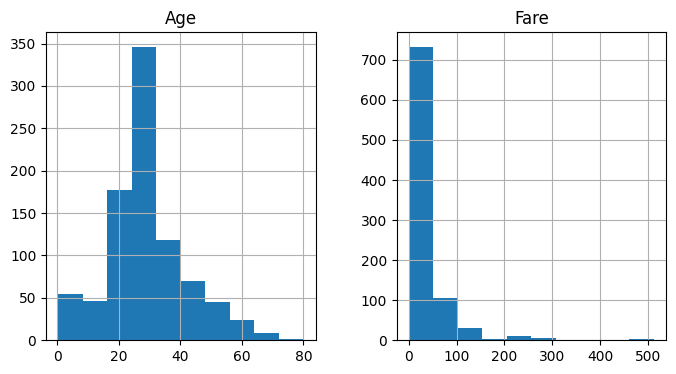

In [12]:
num.hist(figsize=(8,4))
plt.show()

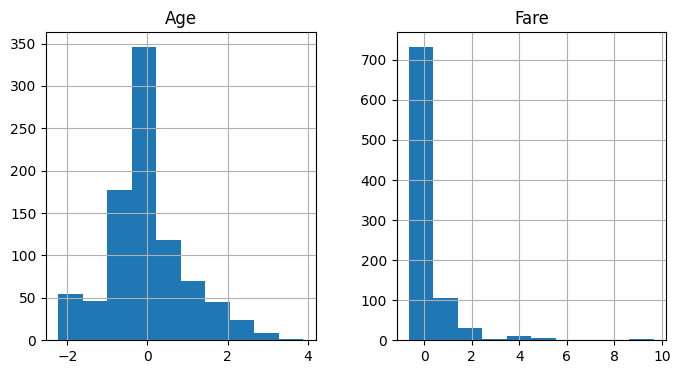

In [13]:
standard=StandardScaler()

standard_scaled=standard.fit_transform(num)

pd.DataFrame(
    standard_scaled,
    columns=['Age','Fare']
).hist(figsize=(8,4))

plt.show()

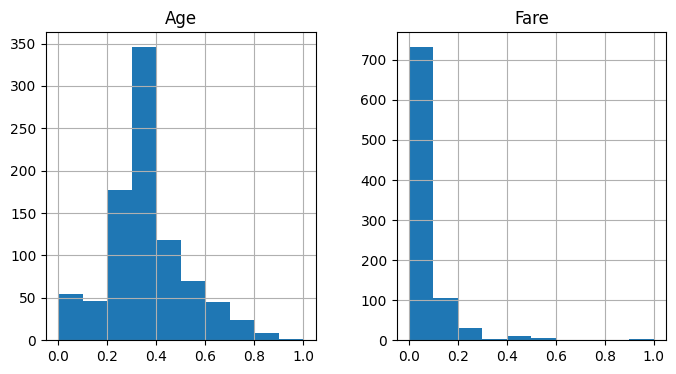

In [14]:
minmax=MinMaxScaler()

minmax_scaled=minmax.fit_transform(num)

pd.DataFrame(
    minmax_scaled,
    columns=['Age','Fare']
).hist(figsize=(8,4))

plt.show()

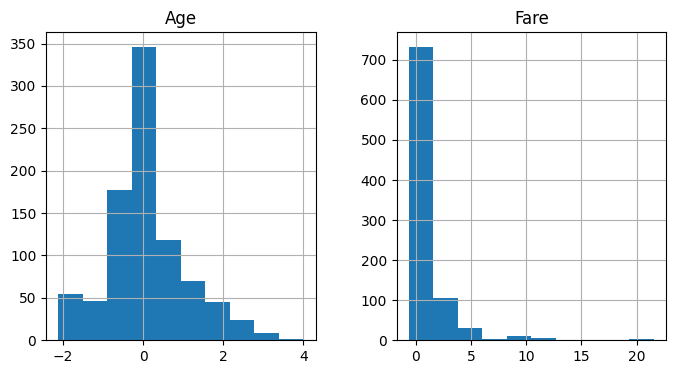

In [15]:
robust=RobustScaler()

robust_scaled=robust.fit_transform(num)

pd.DataFrame(
    robust_scaled,
    columns=['Age','Fare']
).hist(figsize=(8,4))

plt.show()

In [16]:
features=df[['Pclass','Age','SibSp','Parch','Fare','Sex_Label']]

target=df['Survived']

In [18]:
selector=SelectKBest(
    score_func=f_classif,
    k=5
)

selector.fit(features,target)

SelectKBest(k=5)

In [19]:
scores=pd.DataFrame({

'Feature':features.columns,

'Score':selector.scores_

})

scores.sort_values(
by='Score',
ascending=False
)

,Feature,Score
5,Sex_Label,372.405724
0,Pclass,115.031272
4,Fare,63.030764
3,Parch,5.963464
1,Age,3.761528
2,SibSp,1.110572
